# Complaint Analysis 


In [1]:
# =========================
# 0) Imports + Settings
# =========================
import os, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.preprocessing import OneHotEncoder, normalize
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.sparse import hstack

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

DATA_XLSX_PATH = r"Reclamations.xlsx"
assert os.path.exists(DATA_XLSX_PATH), f"File not found: {DATA_XLSX_PATH}"

## 1) Load data 

In [2]:
df = pd.read_excel(DATA_XLSX_PATH, sheet_name=0)

# Types
df["date"] = pd.to_datetime(df["date"], errors="coerce")

# Strip categorical fields
CAT_COLS = ["wilaya","canal","categorie","sentiment","urgence","status","suggested_action"]
for c in CAT_COLS:
    if c in df.columns:
        df[c] = df[c].astype(str).str.strip()

# Derived time features (useful for EDA)
df["month"] = df["date"].dt.to_period("M").astype(str)

print("Shape:", df.shape)
df.head()

Shape: (100000, 11)


,id,date,wilaya,canal,texte_reclamation,categorie,sentiment,urgence,status,suggested_action,month
0,105001,2024-07-31,Tizi Ouzou,Centre d'appel,Incident: modem ne se synchronise pas.,Coupure de ligne,Négatif,Moyenne,Résolu,Redémarrage du modem,2024-07
1,105002,2024-10-29,Boumerdès,Application mobile,Client signale problème lors de la résiliation...,Résiliation,Négatif,Moyenne,En cours,Vérifier décodeur,2024-10
2,105003,2024-03-22,Msila,Site web,Demande d'assistance: bruit important sur la l...,Coupure de ligne,Négatif,Basse,Résolu,Envoi technicien,2024-03
3,105004,2024-04-15,Saïda,Centre d'appel,"Incident: problème lors de la résiliation, fac...",Coupure de ligne,Négatif,Moyenne,Nouveau,Vérifier décodeur,2024-04
4,105005,2025-09-04,Boumerdès,Site web,Incident: installation non réalisée dans les d...,Coupure de ligne,Négatif,Basse,Clôturé,Vérifier décodeur,2025-09


## 2) Quick EDA (counts + trend)

,count
categorie,
Coupure de ligne,22375
Internet lent,20034
Facturation,11891
Télévision,10021
Installation,9871
Assistance,7908
Résiliation,6101
Problème matériel,5879
Configuration,3954


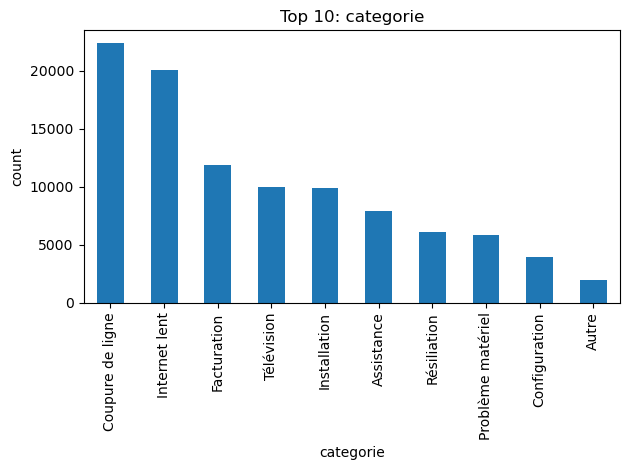

,count
wilaya,
Jijel,3832
Laghouat,3814
Annaba,3778
Batna,3757
Oran,3751
Biskra,3749
Tizi Ouzou,3749
Béjaïa,3743
Blida,3740


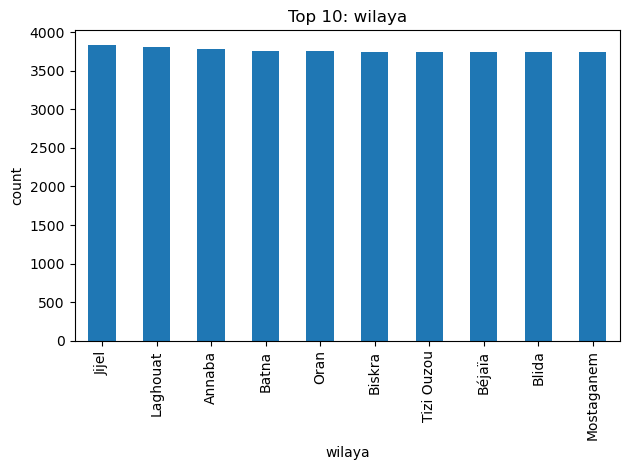

,count
canal,
Centre d'appel,39649
Site web,20085
Agence commerciale,15206
Application mobile,15025
Email,10035


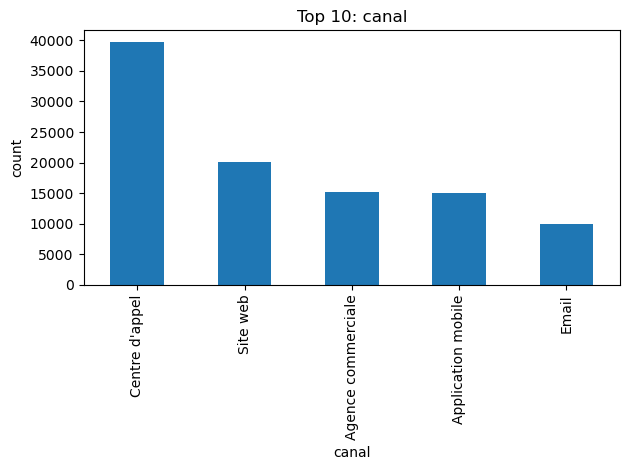

,count
urgence,
Moyenne,40136
Basse,39839
élevée,15131
Critique,4894


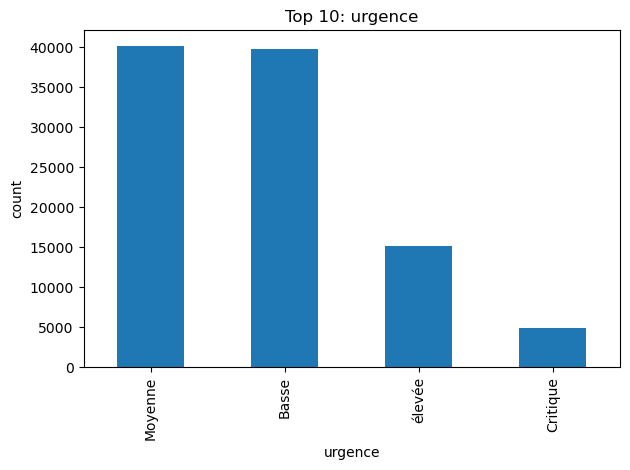

,count
status,
Résolu,35003
En cours,29960
Nouveau,25005
Escaladé,5072
Clôturé,4960


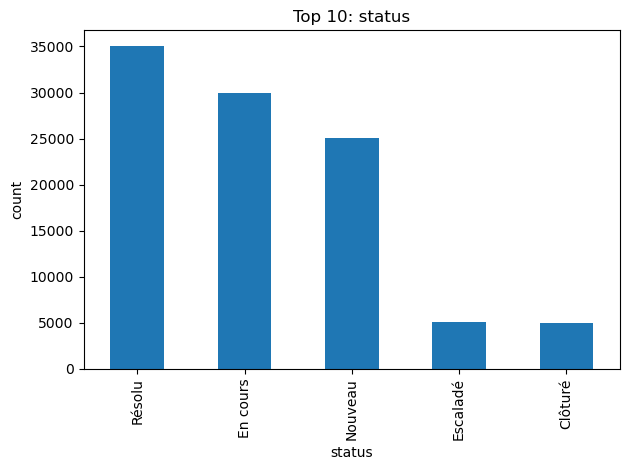

,count
sentiment,
Négatif,60167
Neutre,29883
Positif,9950


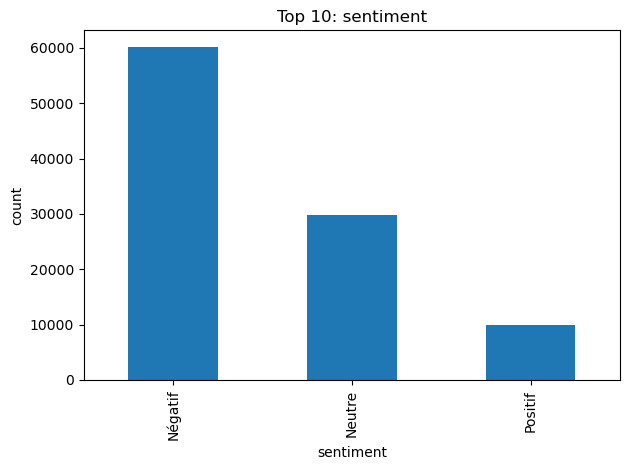

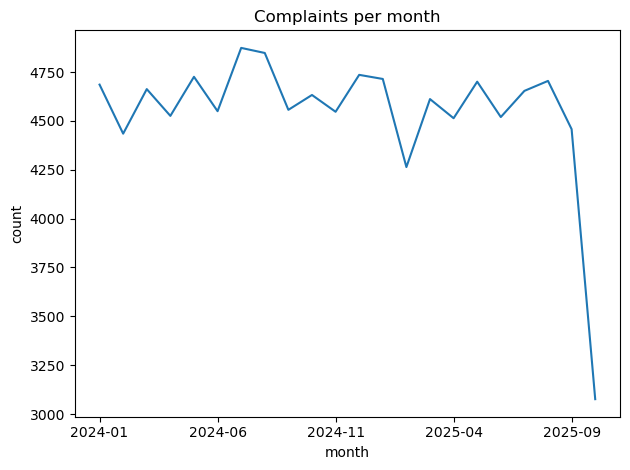

In [3]:
def plot_top_counts(col, top=10):
    vc = df[col].value_counts().head(top)
    display(vc.to_frame("count"))
    plt.figure()
    vc.plot(kind="bar")
    plt.title(f"Top {top}: {col}")
    plt.xlabel(col)
    plt.ylabel("count")
    plt.tight_layout()
    plt.show()

for col in ["categorie","wilaya","canal","urgence","status","sentiment"]:
    plot_top_counts(col, top=10)

# Monthly trend
month_counts = df["month"].value_counts().sort_index()
plt.figure()
month_counts.plot(kind="line")
plt.title("Complaints per month")
plt.xlabel("month"); plt.ylabel("count")
plt.tight_layout(); plt.show()

## 3) Text preprocessing 

In [4]:
# Minimal French stopwords (extend if needed)
FR_STOP = set("""
a au aux avec ce ces dans de des du elle en et eux il je la le les leur lui ma mais me meme mes moi mon ne nos notre nous on ou par pas
pour qu que qui sa se ses son sur ta te tes toi ton tu un une vos votre vous c est d l y s
""".split())

def clean_text_fr(text: str) -> str:
    if pd.isna(text):
        return ""
    t = str(text).lower()
    t = re.sub(r"[’']", " ", t)
    t = re.sub(r"[^a-zàâçéèêëîïôûùüÿñæœ\s]", " ", t)  # keep letters + spaces
    t = re.sub(r"\s+", " ", t).strip()
    tokens = [w for w in t.split() if w not in FR_STOP and len(w) > 2]
    return " ".join(tokens)

df["text_clean"] = df["texte_reclamation"].apply(clean_text_fr)

# TF-IDF text features
tfidf = TfidfVectorizer(ngram_range=(1,2), min_df=5, max_df=0.9)
X_text = tfidf.fit_transform(df["text_clean"])

print("TF-IDF shape:", X_text.shape)

TF-IDF shape: (100000, 128)


## 4) Metadata features (One‑Hot)

In [5]:
# We exclude `categorie` from hybrid features (can be noisy), but keep it for reporting.
META_FEATURES = ["wilaya","canal","urgence","sentiment","status"]
X_meta_raw = df[META_FEATURES].copy()

ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=True)
X_meta = ohe.fit_transform(X_meta_raw)

print("Meta OneHot shape:", X_meta.shape)

Meta OneHot shape: (100000, 44)


## 5)feature space (Text + Metadata)

In [6]:
# Normalize each block so weights behave predictably
X_text_n = normalize(X_text, norm="l2", axis=1)
X_meta_n = normalize(X_meta, norm="l2", axis=1)

ALPHA = 1.0   # text weight
BETA  = 0.7   # metadata weight (tune)

X_hybrid = hstack([X_text_n.multiply(ALPHA), X_meta_n.multiply(BETA)]).tocsr()
print("Hybrid shape:", X_hybrid.shape)

Hybrid shape: (100000, 172)


## 6) Choose K (KMeans) using silhouette

In [7]:
ks = list(range(3, 13))
scores = []

for k in ks:
    km = KMeans(n_clusters=k, random_state=RANDOM_SEED, n_init="auto")
    labels = km.fit_predict(X_hybrid)
    sil = silhouette_score(X_hybrid, labels)
    scores.append(sil)
    print(f"k={k} silhouette={sil:.4f}")

plt.figure()
plt.plot(ks, scores, marker="o")
plt.title("Silhouette vs k (Hybrid)")
plt.xlabel("k"); plt.ylabel("silhouette")
plt.tight_layout(); plt.show()

BEST_K = int(ks[int(np.argmax(scores))])
print("Chosen k:", BEST_K)

k=3 silhouette=0.0973
k=4 silhouette=0.1295


KeyboardInterrupt: 

## 7) KMeans clusters

In [ ]:
kmeans = KMeans(n_clusters=BEST_K, random_state=RANDOM_SEED, n_init="auto")
df["cluster_kmeans_hybrid"] = kmeans.fit_predict(X_hybrid)

df["cluster_kmeans_hybrid"].value_counts().head(10)

cluster_kmeans_hybrid
8    10112
2    10066
1    10048
6    10034
0    10017
9     9996
5     9989
4     9933
3     9909
7     9896
Name: count, dtype: int64

## 8) Interpret clusters

In [ ]:
feature_names = np.array(tfidf.get_feature_names_out())

def top_terms_from_centroid_text(kmeans_model, topn=10):
    # Centroids correspond to hybrid space; extract only text part indices [0:text_dim)
    text_dim = X_text_n.shape[1]
    cent = kmeans_model.cluster_centers_[:, :text_dim]
    tops = {}
    for cid in range(cent.shape[0]):
        idx = np.argsort(cent[cid])[::-1][:topn]
        tops[cid] = feature_names[idx].tolist()
    return tops

tops = top_terms_from_centroid_text(kmeans, topn=10)

def profile_cluster(cid, topn=5):
    part = df[df["cluster_kmeans_hybrid"] == cid]
    return {
        "cluster": cid,
        "n": len(part),
        "top_terms": ", ".join(tops[cid]),
        "top_wilaya": ", ".join(part["wilaya"].value_counts().head(topn).index.astype(str)),
        "top_canal": ", ".join(part["canal"].value_counts().head(topn).index.astype(str)),
        "top_status": ", ".join(part["status"].value_counts().head(topn).index.astype(str)),
        "urgent_%": round(100 * part["urgence"].str.lower().isin(["élevée","critique"]).mean(), 2),
        "escalade_%": round(100 * (part["status"].str.lower() == "escaladé").mean(), 2),
        "examples": " | ".join(part["texte_reclamation"].head(3).tolist())
    }

cluster_profiles = pd.DataFrame([profile_cluster(cid) for cid in sorted(df["cluster_kmeans_hybrid"].unique())])
display(cluster_profiles.sort_values("n", ascending=False))

,cluster,n,top_terms,top_wilaya,top_canal,top_status,urgent_%,escalade_%,examples
8,8,10112,"certaines chaines, certaines, chaines, image f...","Annaba, Biskra, Blida, Laghouat, Msila","Centre d'appel, Site web, Agence commerciale, ...","Résolu, En cours, Nouveau, Clôturé, Escaladé",20.32,4.78,Demande d'assistance: image figée sur certaine...
2,2,10066,"montant facturé, régularisation, demande régul...","Annaba, Blida, Ghardaïa, Sidi Bel Abbès, Skikda","Centre d'appel, Site web, Application mobile, ...","Résolu, En cours, Nouveau, Clôturé, Escaladé",19.53,4.99,Demande d'assistance: montant facturé incorrec...
1,1,10048,"téléphonique, bruit important, ligne téléphoni...","Jijel, Béjaïa, El Oued, Annaba, Tlemcen","Centre d'appel, Site web, Agence commerciale, ...","Résolu, En cours, Nouveau, Clôturé, Escaladé",20.28,4.73,Demande d'assistance: bruit important sur la l...
6,6,10034,"très, soirée, très faible, faible soirée, faib...","Skikda, Tiaret, Béjaïa, Msila, Biskra","Centre d'appel, Site web, Application mobile, ...","Résolu, En cours, Nouveau, Escaladé, Clôturé",19.88,5.06,Réclamation: débit très faible en soirée. | Cl...
0,0,10017,"réalisée délais, installation, installation no...","Sétif, Skikda, Batna, Oran, Biskra","Centre d'appel, Site web, Application mobile, ...","Résolu, En cours, Nouveau, Clôturé, Escaladé",19.78,5.04,Incident: installation non réalisée dans les d...
9,9,9996,"problème lors, lors résiliation, résiliation, ...","El Oued, Laghouat, Mostaganem, Biskra, Jijel","Centre d'appel, Site web, Agence commerciale, ...","Résolu, En cours, Nouveau, Escaladé, Clôturé",19.93,5.33,Client signale problème lors de la résiliation...
5,5,9989,"depuis, matin, coupure, depuis matin, service,...","Béjaïa, Tlemcen, Boumerdès, Tizi Ouzou, Biskra","Centre d'appel, Site web, Agence commerciale, ...","Résolu, En cours, Nouveau, Escaladé, Clôturé",20.20,5.11,Réclamation: coupure de service depuis ce mati...
4,4,9933,"information, contrat, demande information, inf...","Jijel, Laghouat, Adrar, Relizane, Tizi Ouzou","Centre d'appel, Site web, Application mobile, ...","Résolu, En cours, Nouveau, Clôturé, Escaladé",20.52,5.10,Client signale demande d'information sur l'off...
3,3,9909,"erreur authentification, connexion, authentifi...","Sétif, Médéa, Oran, Ouargla, Batna","Centre d'appel, Site web, Agence commerciale, ...","Résolu, En cours, Nouveau, Escaladé, Clôturé",20.26,5.58,Réclamation: erreur d'authentification lors de...
7,7,9896,"synchronise, modem, modem synchronise, réclama...","Annaba, Constantine, Jijel, Ghardaïa, Laghouat","Centre d'appel, Site web, Agence commerciale, ...","Résolu, En cours, Nouveau, Escaladé, Clôturé",19.54,5.01,Incident: modem ne se synchronise pas. | Clien...


## 9) HDBSCAN (outliers)

In [ ]:
try:
    import hdbscan

    # Use a manageable sample for speed
    N_HDB = 25000
    df_h = df.sample(min(N_HDB, len(df)), random_state=RANDOM_SEED).copy()
    idx = df_h.index
    Xh = X_hybrid[idx, :]

    hdb = hdbscan.HDBSCAN(min_cluster_size=80, min_samples=15)
    df_h["cluster_hdbscan_hybrid"] = hdb.fit_predict(Xh)

    print("HDBSCAN counts (includes -1 noise):")
    display(df_h["cluster_hdbscan_hybrid"].value_counts().head(20))
except Exception as e:
    print("HDBSCAN not available:", e)

HDBSCAN counts (includes -1 noise):


cluster_hdbscan_hybrid
3     2558
2     2553
9     2532
4     2516
1     2506
5     2499
0     2483
6     2454
8     2448
7      504
10     500
12     494
11     485
13     468
Name: count, dtype: int64

## 10) Priority matrix (what to fix first)

In [ ]:
def is_high_urg(s): 
    return str(s).lower() in ["élevée","critique"]

def is_negative(s):
    return str(s).lower() == "négatif"

def is_unresolved(s):
    return str(s).lower() in ["nouveau","en cours","escaladé"]

grp = df.groupby("cluster_kmeans_hybrid")

priority = grp.agg(
    n=("id","count"),
    high_urg_rate=("urgence", lambda x: np.mean([is_high_urg(v) for v in x])),
    neg_rate=("sentiment", lambda x: np.mean([is_negative(v) for v in x])),
    unresolved_rate=("status", lambda x: np.mean([is_unresolved(v) for v in x])),
).reset_index()

# Weighted score (tune weights)
priority["priority_score"] = (
    0.40 * (priority["n"] / priority["n"].max()) +
    0.25 * priority["high_urg_rate"] +
    0.20 * priority["unresolved_rate"] +
    0.15 * priority["neg_rate"]
)

priority = priority.sort_values("priority_score", ascending=False)
display(priority.head(10))

,cluster_kmeans_hybrid,n,high_urg_rate,neg_rate,unresolved_rate,priority_score
8,8,10112,0.203224,0.606210,0.597013,0.661140
1,1,10048,0.202826,0.600617,0.600318,0.658331
0,0,10017,0.197764,0.614455,0.601577,0.658167
2,2,10066,0.195311,0.595371,0.602722,0.656858
9,9,9996,0.199280,0.604142,0.599940,0.655841
5,5,9989,0.202022,0.597257,0.602663,0.655761
6,6,10034,0.198824,0.598465,0.594180,0.655226
4,4,9933,0.205175,0.601228,0.600926,0.654582
3,3,9909,0.202644,0.598648,0.603391,0.653106
7,7,9896,0.195432,0.600243,0.601051,0.650560


## 11) Export outputs 

In [ ]:
OUT_PROFILE = "cluster_profiles_kmeans_hybrid.csv"
OUT_PRIORITY = "cluster_priority_kmeans_hybrid.csv"

cluster_profiles.to_csv(OUT_PROFILE, index=False)
priority.to_csv(OUT_PRIORITY, index=False)

print("✅ Saved:", OUT_PROFILE)
print("✅ Saved:", OUT_PRIORITY)

✅ Saved: cluster_profiles_kmeans_hybrid.csv
✅ Saved: cluster_priority_kmeans_hybrid.csv


In [ ]:
# =========================
#  Hybrid clustering (Text TF-IDF + Metadata OneHot) for full datat
# =========================
from sklearn.preprocessing import normalize
from scipy.sparse import hstack

# --- 1) Text features (TF-IDF) ---
tfidf = TfidfVectorizer(ngram_range=(1,2), min_df=5, max_df=0.9)
X_text = tfidf.fit_transform(df["text_clean"].fillna(""))

# --- 2) Metadata features (OneHot) ---
META_FEATURES = ["wilaya", "canal", "urgence", "sentiment", "status"]
ohe_hybrid = OneHotEncoder(handle_unknown="ignore", sparse_output=True)
X_meta = ohe_hybrid.fit_transform(df[META_FEATURES].astype(str))

# --- 3) Hybrid matrix (weighted + normalized) ---
ALPHA = 1.0
BETA = 0.7
X_hybrid = hstack([
    normalize(X_text, norm="l2", axis=1).multiply(ALPHA),
    normalize(X_meta, norm="l2", axis=1).multiply(BETA),
]).tocsr()

print("TF-IDF:", X_text.shape, "| Meta:", X_meta.shape, "| Hybrid:", X_hybrid.shape)

# --- 4) Choose k by silhouette ---
ks = list(range(3, 13))
scores = []
for k in ks:
    km = KMeans(n_clusters=k, random_state=RANDOM_SEED, n_init="auto")
    labels = km.fit_predict(X_hybrid)
    scores.append(silhouette_score(X_hybrid, labels))
best_k = int(ks[int(np.argmax(scores))])

plt.figure()
plt.plot(ks, scores, marker="o")
plt.title("Silhouette vs k (Hybrid KMeans)")
plt.xlabel("k")
plt.ylabel("silhouette")
plt.tight_layout()
plt.show()

print("Chosen k:", best_k)

# --- 5) Fit final KMeans + store labels ---
kmeans = KMeans(n_clusters=best_k, random_state=RANDOM_SEED, n_init="auto")
df["cluster_kmeans_hybrid"] = kmeans.fit_predict(X_hybrid)

df["cluster_kmeans_hybrid"].value_counts().head()

In [ ]:
# =========================
# Compact "Insight → Decision" table
# Cluster → top wilayas → top channels → unresolved% → high urgency% → decision
# =========================

assert "cluster_kmeans_hybrid" in df.columns, (
    "Missing column 'cluster_kmeans_hybrid'. Run the hybrid clustering cell first."
 )

def is_high_urg(s):
    return str(s).strip().lower() in ["élevée", "elevee", "critique"]

def is_unresolved(s):
    return str(s).strip().lower() in ["nouveau", "en cours", "escaladé", "escalade"]

def top_join(series, n=3):
    return ", ".join(series.value_counts().head(n).index.astype(str))

# Build summary
rows = []
for cid, g in df.groupby("cluster_kmeans_hybrid"):
    unresolved_pct = 100 * g["status"].apply(is_unresolved).mean()
    highurg_pct = 100 * g["urgence"].apply(is_high_urg).mean()

    # Simple decision rule (edit to match your story)
    if unresolved_pct >= 62 or highurg_pct >= 22:
        decision = "Priority: fast-track + escalate"
    elif unresolved_pct >= 58:
        decision = "Improve resolution workflow"
    else:
        decision = "Self-service / standard handling"

    rows.append({
        "cluster": int(cid),
        "n": int(len(g)),
        "top_wilayas": top_join(g["wilaya"], n=3),
        "top_channels": top_join(g["canal"], n=3),
        "unresolved_%": round(unresolved_pct, 2),
        "high_urgency_%": round(highurg_pct, 2),
        "decision": decision,
    })

compact_table = (
    pd.DataFrame(rows)
    .sort_values(["unresolved_%", "high_urgency_%", "n"], ascending=False)
    .reset_index(drop=True)
 )

display(compact_table)